# CO543: Image Processing - Lab 3 (2025)
## Noise Removal & Structure Preservation
## E/21/245


### Task 1 — Simulate Salt-and-Pepper Noise

In [9]:
%pip install opencv-python
%pip install matplotlib
%pip install numpy


Note: you may need to restart the kernel to use updated packages.
  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp312-cp312-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.3 kB)
  Using cached pillow-12.1.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.1-py3-none-any.whl.metadata (5.6 kB)
Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.

In [10]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [17]:
# load the image in grayscale
image = cv2.imread("face.jpg",cv2.IMREAD_GRAYSCALE)


In [18]:
noisy_img =  image.copy()

In [19]:
# Add the "salt" noise (white dots) we generate a random number and the 
# if the number is less than the threshold we set, we set that pixel to white

noisy_img[np.random.rand(*image.shape)<0.02] = 255

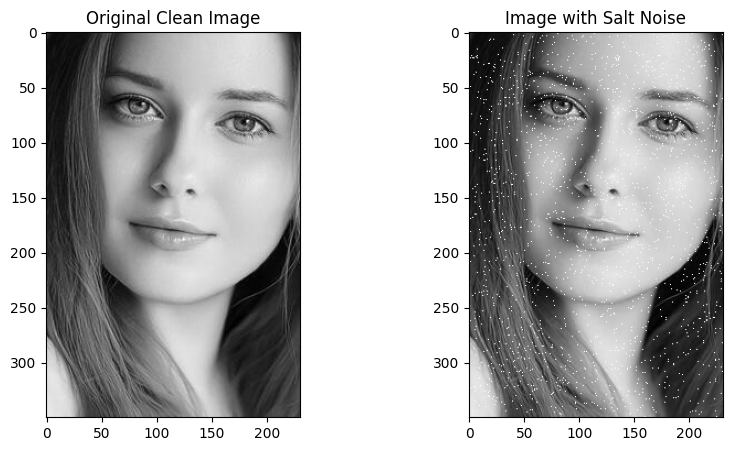

In [20]:
# Display the results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Clean Image")
plt.imshow(image, cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Image with Salt Noise")
plt.imshow(noisy_img, cmap='gray')
plt.show()

#### Observation:-
Adding salt noise introduced random white dots to the image. This broke the smooth edges of facial features (like eyes and lips) and ruined the skin texture, making the face look jagged and disconnected instead of smooth.

##### Discussion:- Why Noise is worse than Blur?
Blur is less damaging because it just spreads the existing information (averaging), so the main shapes are still there. Random noise is worse because it completely deletes the true pixel data and replaces it with false values, effectively destroying the image details.

### Task 2 — Apply Mean Filter

In [21]:
img_noisy = cv2.imread('sample.jpg', cv2.IMREAD_GRAYSCALE)

In [26]:
mean_filtered = cv2.blur(img_noisy,(3,3))

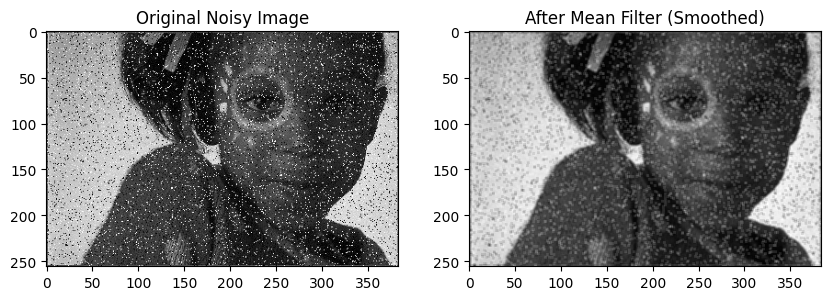

In [27]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Noisy Image")
plt.imshow(img_noisy, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("After Mean Filter (Smoothed)")
plt.imshow(mean_filtered, cmap='gray')
plt.show()

#### Observation: I applied a 3x3 Mean Filter (Average Filter) to the noisy image.

- Result:- The white noise dots were significantly reduced because their high intensity (255) was averaged out with the surrounding darker pixels.

- Drawback:- The image became noticeably blurry. The sharp edges of the face lost their definition because the filter blindly mixes edge pixels with their neighbors, destroying fine details.

#### Discussion (More to think):- Why is blurring acceptable in low-detail backgrounds?
 Blurring is acceptable in backgrounds (like a plain wall or sky) because these areas usually lack sharp edges or fine textures. Since there is no detailed structure to preserve, the blurring simply smooths out the noise without causing any loss of important information.

### Task 3 — Median Filter for Salt-Pepper

In [28]:
median_filtered = cv2.medianBlur(img_noisy, 3)

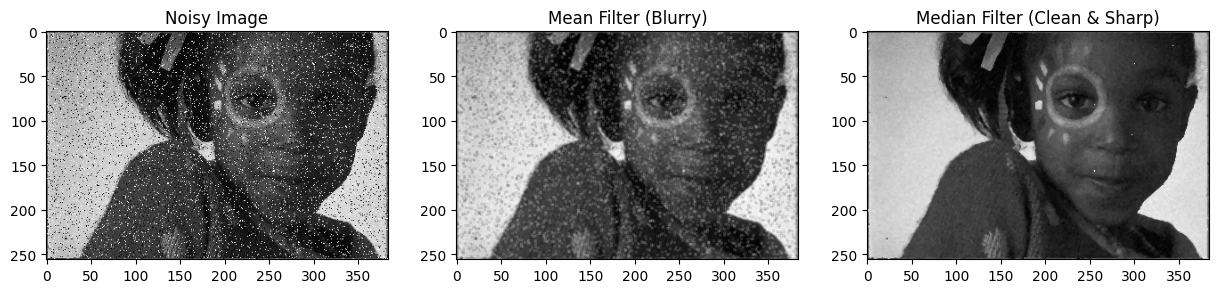

In [29]:
# Display Comparison
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Noisy Image")
plt.imshow(img_noisy, cmap='gray')
plt.subplot(1, 3, 2)
plt.title("Mean Filter (Blurry)")
plt.imshow(mean_filtered, cmap='gray') 

plt.subplot(1, 3, 3)
plt.title("Median Filter (Clean & Sharp)")
plt.imshow(median_filtered, cmap='gray')
plt.show()

#### Observation: I applied a 3x3 Median Filter to the noisy image.

- Result:- The Median Filter completely removed the salt-and-pepper noise without blurring the image. Unlike the Mean Filter, the edges remained sharp and the details of the face were preserved perfectly.

- Comparison:- While the Mean Filter "smudged" the noise into the background, the Median Filter effectively "rejected" the noise pixels, restoring the original look of the image.

#### Discussion (More to think): Why does median treat noise differently from mean? 
The Median filter is a non-linear filter that selects the statistical median (middle value) of a neighborhood.

- Mean Filter: Includes the noise value in the calculation (averaging), which spreads the error and causes blurring.

- Median Filter: Sorts the pixel values and picks the middle one. Since noise values (like 0 or 255) are usually extreme outliers, they end up at the very beginning or very end of the sorted list. Therefore, the median (middle value) is almost always a "real" pixel from the image, effectively discarding the noise completely.

### Task 4 — Gaussian Smoothing


In [30]:
gaussian_blur = cv2.GaussianBlur(img_noisy, (5,5),1)


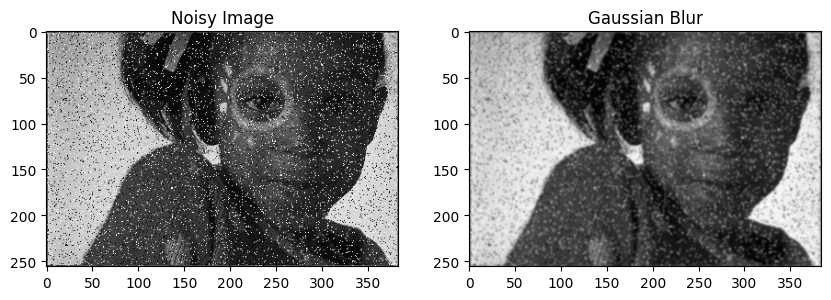

In [31]:
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.title("Noisy Image")      
plt.imshow(img_noisy, cmap='gray')      
plt.subplot(1,2,2)
plt.title("Gaussian Blur")
plt.imshow(gaussian_blur, cmap='gray')
plt.show()

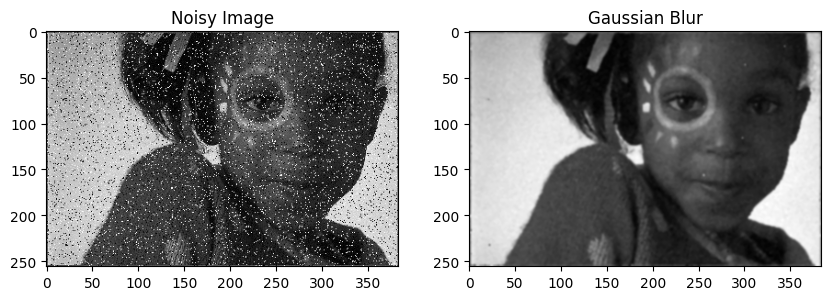

In [40]:
# Apply Gaussian Blur to the Median Filtered Image
gaussian_blur = cv2.GaussianBlur(median_filtered, (5,5),1)
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.title("Noisy Image")      
plt.imshow(img_noisy, cmap='gray')      
plt.subplot(1,2,2)
plt.title("Gaussian Blur")
plt.imshow(gaussian_blur, cmap='gray')
plt.show()

#### Observation: I applied a 5x5 Gaussian Blur with a standard deviation (sigma) of 1.

- Result:- The noise was reduced, but unlike the Mean Filter, the image retained more of its original structure. The blurring effect appeared softer and less harsh.

- Trade-off:- While it is better than the Mean Filter, it still blurs the edges to some extent. It balances noise removal with edge preservation better than a simple average but not as sharply as the Median Filter for salt-and-pepper noise.

#### Discussion (More to think): Why does Gaussian blur feel visually “natural”? 
Gaussian blur mimics the way light naturally diffuses in the physical world.

- Physics: Optical systems (like cameras and human eyes) naturally blur out-of-focus light according to a Gaussian distribution (Point Spread Function).

- Weighting: Unlike the Mean filter which gives equal weight to all pixels (creating a harsh, artificial look), Gaussian blur gives more weight to the center pixels and gradually less to the neighbors. This creates a smooth, continuous transition that looks pleasing and natural to the human eye.


### Task 5 — Bilateral Filtering for Edge Preservation

In [41]:
bilateral_filtered = cv2.bilateralFilter(median_filtered, d=9, sigmaColor=60, sigmaSpace=60)

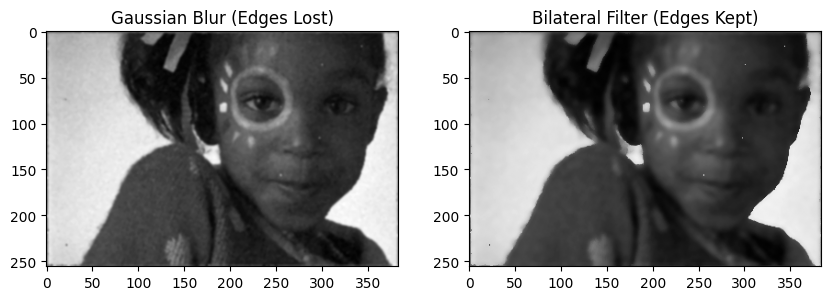

In [42]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Gaussian Blur (Edges Lost)")
plt.imshow(gaussian_blur, cmap='gray') 

plt.subplot(1, 2, 2)
plt.title("Bilateral Filter (Edges Kept)")
plt.imshow(bilateral_filtered, cmap='gray')
plt.show()

#### Observation:-
I applied the Bilateral Filter (d=9, sigmaColor=60, sigmaSpace=60) to the noisy image.

- Result:- The skin texture became very smooth, effectively removing the noise in flat areas. However, unlike Gaussian blur, the sharp edges of the eyes, nose, and jawline remained crisp and defined.

- Facial Identity: Facial identity relies heavily on the "discontinuities" or sharp lines that define features. Since the Bilateral filter smoothes similar colors but stops at edges (large intensity differences), it preserves the structural map of the face while cleaning the skin.

#### Discussion (More to think):- Why are edge-aware filters more computationally expensive? 
Bilateral filtering is much slower than Gaussian or Mean filtering because it is non-linear and adaptive.

- Gaussian/Mean: Uses a fixed kernel (recipe) that is the same for every single pixel. It can be calculated very fast.

- Bilateral: The kernel changes for every single pixel. For each pixel, the computer has to check its neighbors' values, calculate the intensity difference, and create a unique weight distribution dynamically. If an image has 1 million pixels, the computer essentially builds 1 million different filters.

### Task 6 — Laplacian Sharpening

In [43]:
lap = cv2.Laplacian(bilateral_filtered, cv2.CV_64F )

In [44]:
bilateral_float = bilateral_filtered.astype(np.float64)
sharpened = cv2.subtract(bilateral_float, lap)

In [45]:
sharp_display = cv2.convertScaleAbs(sharpened)
lap_display = cv2.convertScaleAbs(lap)

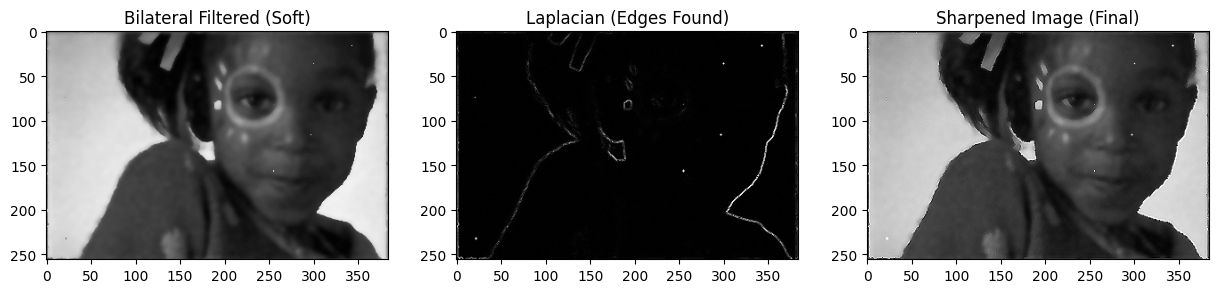

In [46]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Bilateral Filtered (Soft)")
plt.imshow(bilateral_filtered, cmap='gray')

plt.subplot(1, 3, 2)
plt.title("Laplacian (Edges Found)")
plt.imshow(lap_display, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("Sharpened Image (Final)")
plt.imshow(sharp_display, cmap='gray')
plt.show()

#### Noise Re-magnification :-

When sharpening is applied to an image where noise hasn't been effectively removed (e.g., using Bilateral filter on Salt-and-Pepper noise), the Laplacian operator detects the noise pixels as edges. This results in 're-magnifying' the noise, making the final image look grainier than the original.

#### Proper Structure Preservation :-

To achieve a good sharpened result, noise must be completely eliminated first (e.g., using a Median filter). This ensures the Laplacian operator only detects distinct facial features, allowing us to enhance structural details without amplifying artifacts.

#### Discussion (More to think):- Can sharpening fully recover high-frequency details lost during filtering? 
No. This is a fundamental rule in information theory. Smoothing filters (like Mean, Gaussian, or even Bilateral) work by removing high-frequency information (fine details) to kill noise. Once this information is removed, it is lost forever. Sharpening does not bring back lost details; it only increases the contrast of the edges that remain after filtering. You cannot "un-blur" an image to recover data that isn't there anymore.

### Final Reflection:-

In this experiment, the Median Filter proved to be the best method for removing Salt-and-Pepper noise. While Mean and Gaussian filters made the image blurry, and the Bilateral filter failed to remove the noise dots (mistaking them for edges), the Median filter worked perfectly. It successfully removed the noise without blurring the face, offering the best balance between cleaning the image and preserving important details.